# 2_analysis (utils-based)
Ноутбук очищен: функции вынесены в `tcrempnet_utils.py`, вызовы заменены на `utils.<fn>()`,
пустые и служебные ячейки удалены.

In [1]:
import pandas as pd
from mir.common.segments import SegmentLibrary

In [3]:
import sys, importlib
# sys.path.append('/mnt/data')
import tcrempnet_utils as utils
importlib.reload(utils)
print('utils loaded; available:', len([n for n in dir(utils) if callable(getattr(utils, n, None))]))


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


utils loaded; available: 51


In [4]:
import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
samples = """HIP00594  HIP00777  HIP03370  HIP03511  HIP03720  
HIP04509  HIP05559  HIP05815  HIP05960  HIP08653  
HIP08986  HIP09020  HIP10716  HIP11937  HIP12900  
HIP13513  HIP13903  HIP13967  HIP13986  HIP13994  
HIP14041  HIP14051  HIP14157  HIP14194  HIP14227  
HIP15854""".split()

In [8]:
sample_to_data = {}
for sample in samples:
    try:
        info = utils.get_sample_info(sample)
        df = utils.get_clonotypes(sample)
        info[0]['vdjdb_valid'] = info[0].cluster_id.apply(lambda x: utils.get_cluster_matches_vdjdb(df, x, vdjdb))
        info[0]['vdjdb_nonvalid'] = info[0].cluster_id.apply(lambda x: utils.get_cluster_matches_vdjdb(df, x, nonvdjdb))
        sample_to_data[sample] = info
    except Exception as e:
        print(f'Problem with {sample}, {e}')


    sample: HIP00594
    clusters: 22817
    overall from sample: 155820
    
Problem with HIP00594, name 'vdjdb' is not defined

    sample: HIP00777
    clusters: 25239
    overall from sample: 254385
    
Problem with HIP00777, name 'vdjdb' is not defined

    sample: HIP03370
    clusters: 26555
    overall from sample: 293545
    
Problem with HIP03370, name 'vdjdb' is not defined

    sample: HIP03511
    clusters: 23870
    overall from sample: 202864
    
Problem with HIP03511, name 'vdjdb' is not defined

    sample: HIP03720
    clusters: 22676
    overall from sample: 147646
    
Problem with HIP03720, name 'vdjdb' is not defined

    sample: HIP04509
    clusters: 22531
    overall from sample: 142950
    
Problem with HIP04509, name 'vdjdb' is not defined

    sample: HIP05559
    clusters: 25794
    overall from sample: 267339
    
Problem with HIP05559, name 'vdjdb' is not defined

    sample: HIP05815
    clusters: 19527
    overall from sample: 29639
    
Problem with


KeyboardInterrupt



In [51]:
samples = list(sample_to_data.keys())

In [52]:
len(samples)

22

In [73]:
s_res[0]

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change,vdjdb_valid,vdjdb_nonvalid
0,0,3,2,1,0.004869,0.043245,0.762758,False,False
1,1,7,4,3,0.003593,0.043245,0.586667,False,False
2,2,10,6,4,0.000085,0.002328,0.637820,False,False
3,3,4,2,2,0.115171,0.537866,0.461728,False,False
4,4,3,1,2,0.709791,0.826517,0.160698,False,False
...,...,...,...,...,...,...,...,...,...
25486,25486,3,0,3,0.308734,0.537866,-9.015393,False,False
25487,25487,3,0,3,0.308734,0.537866,-9.015393,False,False
25488,25488,3,0,3,0.308734,0.537866,-9.015393,False,False
25489,25489,3,0,3,0.308734,0.537866,-9.015393,False,False


In [79]:
t = s_res[0]
t[t.vdjdb_nonvalid | t.vdjdb_valid]

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change,vdjdb_valid,vdjdb_nonvalid
55,55,3,2,1,4.868938e-03,4.324533e-02,0.762758,True,True
1715,1715,8,6,2,1.677409e-10,9.059076e-09,0.938849,True,True
2020,2020,4,3,1,6.266105e-06,1.892527e-04,0.938849,True,False
3237,3237,5,4,1,5.008696e-10,2.422707e-08,1.063788,True,False
4738,4738,3,2,1,4.868938e-03,4.324533e-02,0.762758,False,True
4955,4955,5,3,2,5.459346e-03,4.490616e-02,0.637820,True,False
5416,5416,7,4,3,3.592808e-03,4.324533e-02,0.586667,True,True
6026,6026,3,3,0,0.000000e+00,0.000000e+00,9.938849,True,False
9325,9325,3,2,1,4.868938e-03,4.324533e-02,0.762758,True,False
9960,9960,7,4,3,3.592808e-03,4.324533e-02,0.586667,True,False


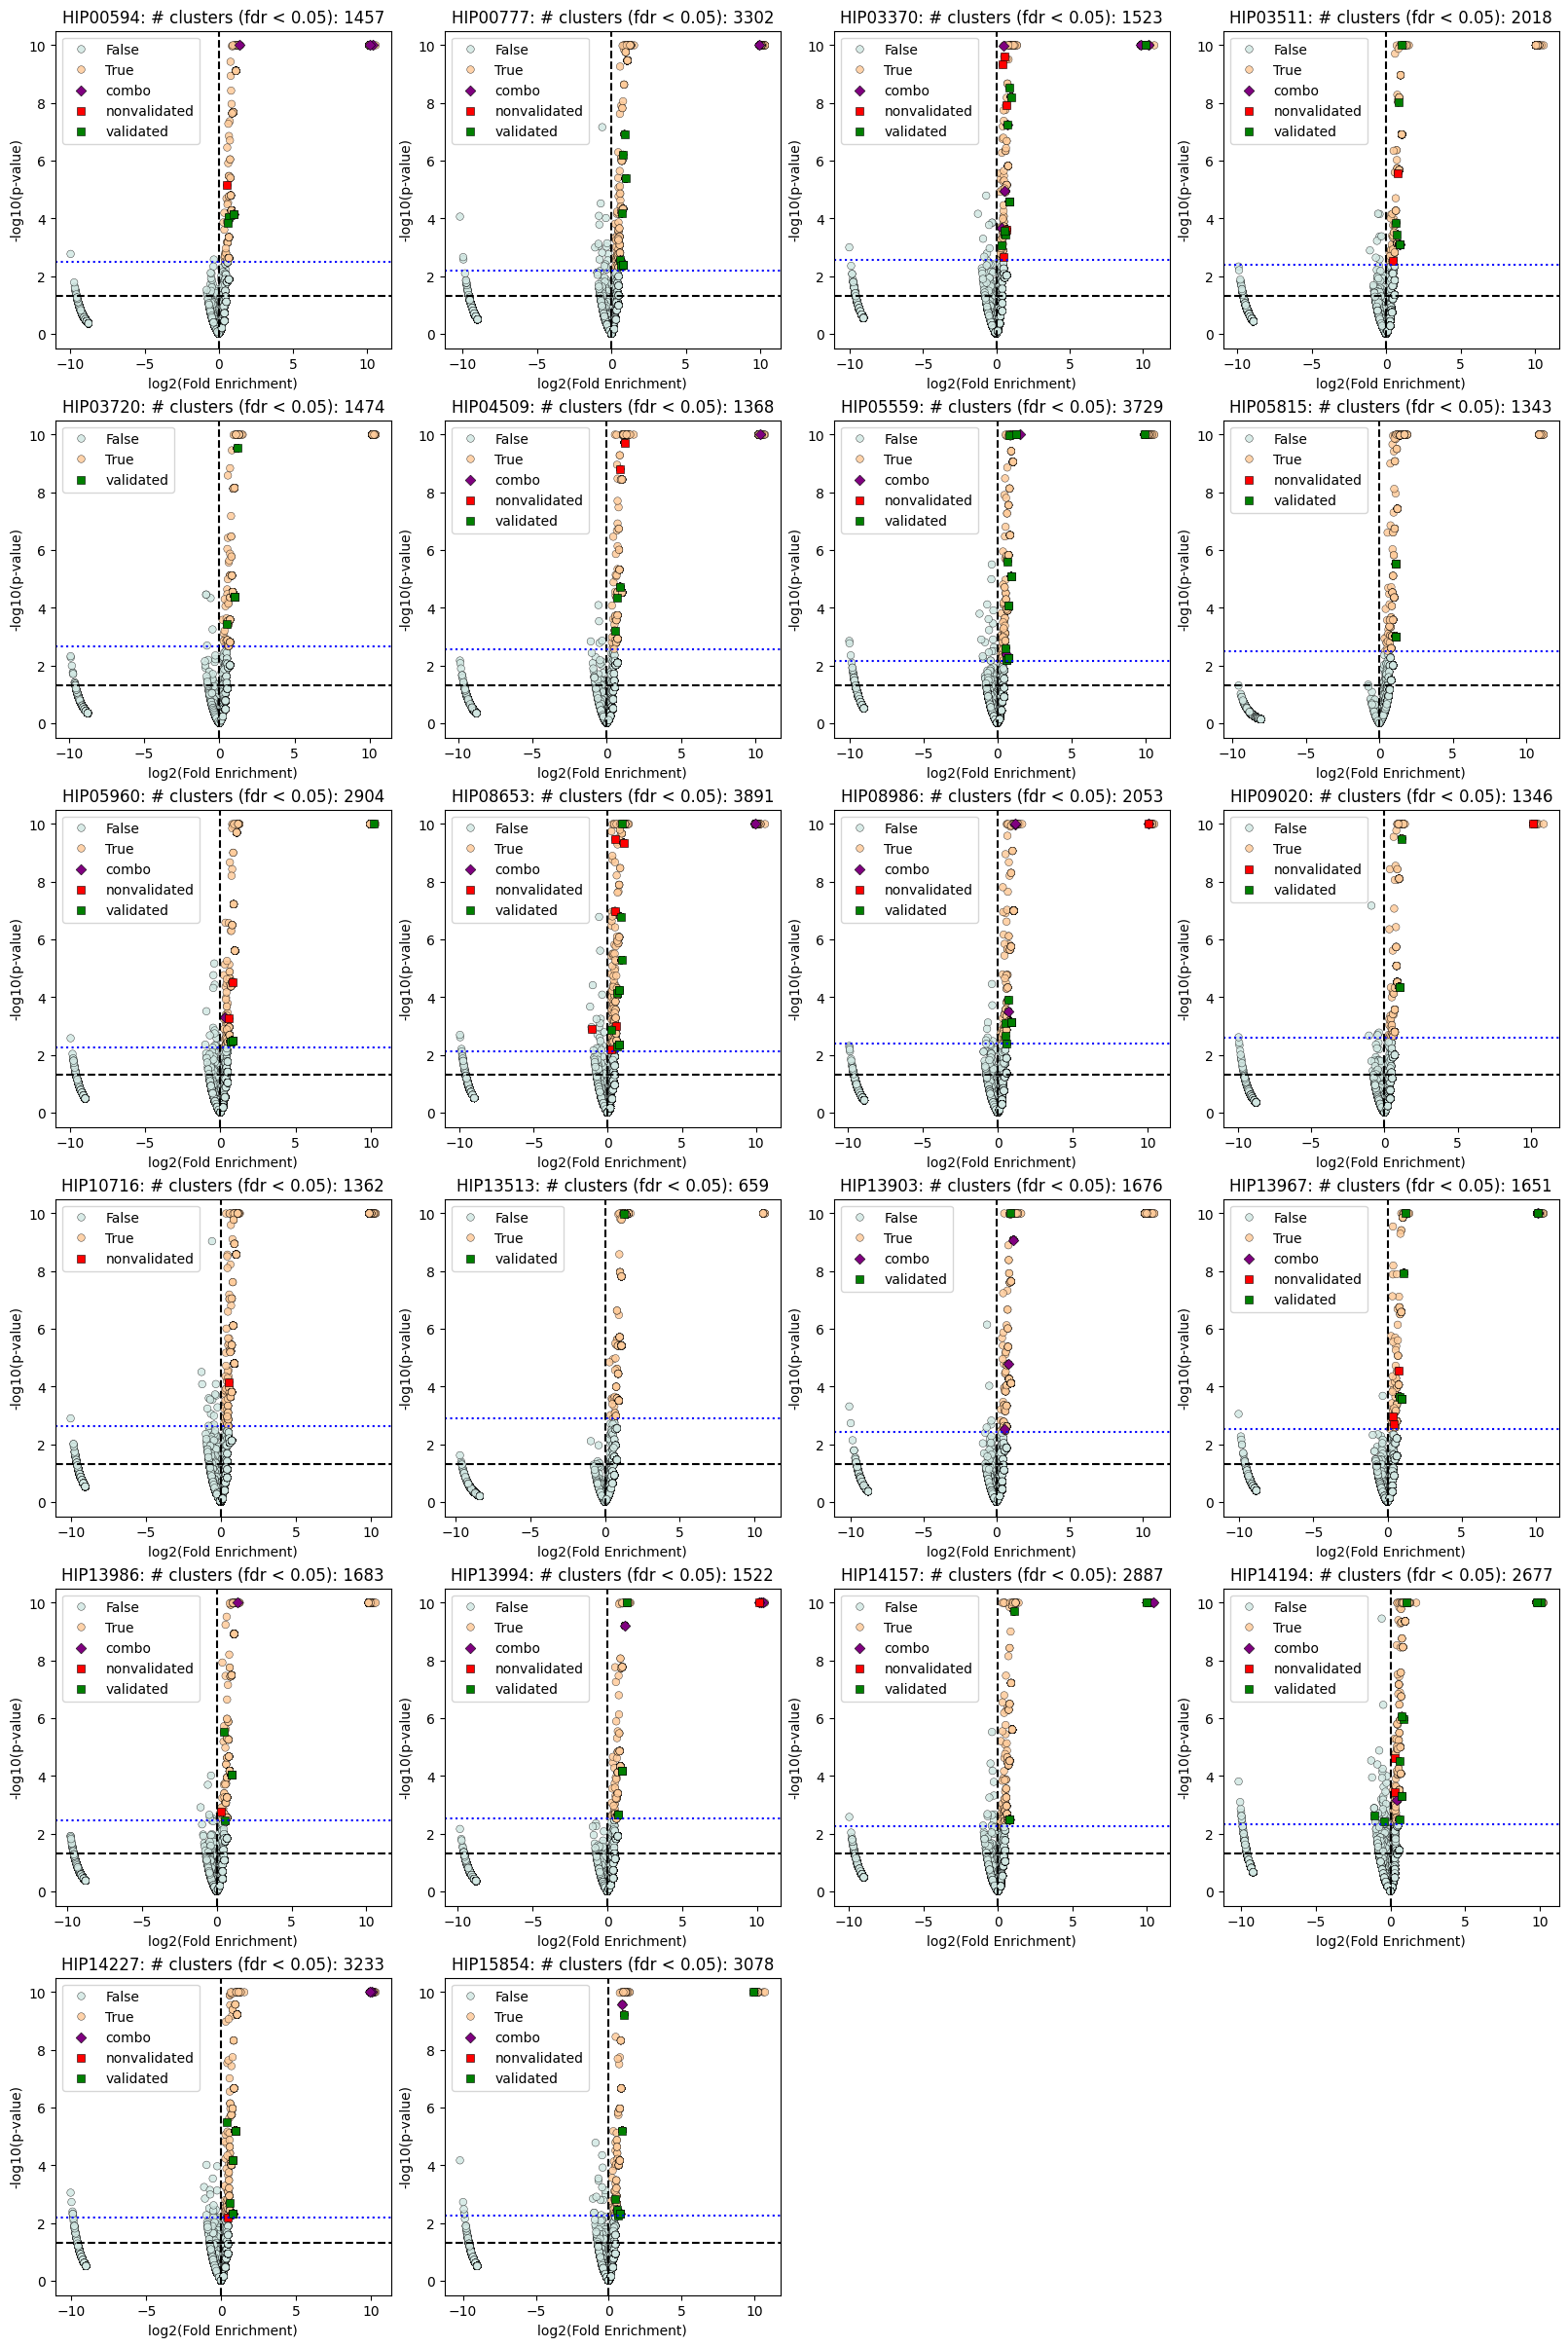

In [87]:
ncols = 4
nrows = 6
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4), constrained_layout=True)
for i, s in enumerate(samples):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    s_res = sample_to_data[s]
    # utils.plot_volcano(s_res[0], ax=ax)
    utils.plot_volcano(
        s_res[0],
        sample_name=s,
        ax=ax,
        layers=[
            {"col": "vdjdb_nonvalid", "marker": "s", "color": "red", "label": "nonvalidated"},
            {"col": "vdjdb_valid", "marker": "s", "color": "green", "label": "validated"},
        ],
        layer_exclusive=False, point_size=30
    )

# Удалим лишние пустые сабплоты (если samples < 27)
for j in range(len(samples), ncols * nrows):
    fig.delaxes(axes[j // ncols, j % ncols])
plt.savefig('as_volcanos.png', dpi=300)
plt.show()

In [89]:
all_info = []
for s in samples:
    s_res = sample_to_data[s][0]
    res_df = s_res[['cluster_id', 'vdjdb_valid', 'vdjdb_nonvalid', 'enrichment_fdr_zbinom', 'log_fold_change']]
    res_df = res_df[(res_df.enrichment_fdr_zbinom < 0.05) & (res_df.log_fold_change > 0)]
    res_df['sample'] = s
    all_info.append(res_df)

In [90]:
joint = pd.concat(all_info)

In [91]:
joint

,cluster_id,vdjdb_valid,vdjdb_nonvalid,enrichment_fdr_zbinom,log_fold_change,sample
0,0,False,False,0.001280,0.989084,HIP00594
2,2,False,False,0.037046,0.688054,HIP00594
6,6,False,False,0.001280,0.989084,HIP00594
7,7,False,False,0.000000,10.290114,HIP00594
11,11,False,False,0.000000,10.165175,HIP00594
...,...,...,...,...,...,...
25435,25435,False,False,0.043245,0.762758,HIP15854
25441,25441,False,False,0.043245,0.762758,HIP15854
25452,25452,False,False,0.043245,0.762758,HIP15854
25464,25464,False,False,0.043245,0.762758,HIP15854


In [92]:
joint = joint.rename(columns={'log_fold_change': 'fold_enrichment', 'enrichment_fdr_zbinom': 'pvalue'})

In [94]:
joint[joint.vdjdb_valid].sort_values(by='sample')

,cluster_id,vdjdb_valid,vdjdb_nonvalid,pvalue,fold_enrichment,sample
137,137,True,True,0.000000,10.387024,HIP00594
3028,3028,True,True,0.001280,0.989084,HIP00594
4572,4572,True,False,0.001497,0.688054,HIP00594
4799,4799,True,True,0.000000,1.387024,HIP00594
5003,5003,True,False,0.002391,0.621107,HIP00594
...,...,...,...,...,...,...
6026,6026,True,False,0.000000,9.938849,HIP15854
9325,9325,True,False,0.043245,0.762758,HIP15854
9960,9960,True,False,0.043245,0.586667,HIP15854
10124,10124,True,False,0.038185,0.420336,HIP15854


In [95]:
all_clonotypes_enriched = []
for patient in samples:
    t = utils.get_clonotypes(patient).drop(columns=['enrichment_pvalue_zbinom'])
    # t = t[t.source == 'sample']
    t = t[t.cluster_id.isin(joint[joint['sample'] == patient].cluster_id)]
    t['cluster_id'] = patient + '_c' + t.cluster_id.astype(str)
    t['sample_name'] = patient
    all_clonotypes_enriched.append(t)

In [96]:
data = pd.concat(all_clonotypes_enriched)#.drop(columns=['source'])
data

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name
0,s_22,HIP00594_c0,CASSLDAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594
1,s_10307,HIP00594_c0,CASSLDSYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594
2,b_594538,HIP00594_c0,CASSLNAYEQYF,TRBV4-2*01,TRBJ2-7*01,background,HIP00594
3,s_41,HIP00594_c2,CASSEGTGGTDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594
4,s_42248,HIP00594_c2,CASSDGAGGRDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594
...,...,...,...,...,...,...,...
13956,s_261169,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,sample,HIP15854
13957,b_85098,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,background,HIP15854
13958,s_261268,HIP15854_c19999,CASRLAGTTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854
13959,s_261294,HIP15854_c19999,CAWRIAGNTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854


In [98]:
data['vdjdb_valid'] = data.cdr3aa_beta.apply(lambda x: utils.has_vdjdb_match(x, vdjdb) > 0)
data['vdjdb_nonvalid'] = data.cdr3aa_beta.apply(lambda x: utils.has_vdjdb_match(x, nonvdjdb) > 0)

In [101]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in data.cdr3aa_beta]
dataset = ClonotypeDataset(found_clonotypes)

In [102]:
df = data

In [105]:
df, mapping = utils.merge_clusters_by_shared_cdr3(df)

In [106]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb_valid,vdjdb_nonvalid,merged_cluster_id
0,s_22,HIP00594_c0,CASSLDAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594,False,False,0
1,s_10307,HIP00594_c0,CASSLDSYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594,False,False,0
2,b_594538,HIP00594_c0,CASSLNAYEQYF,TRBV4-2*01,TRBJ2-7*01,background,HIP00594,False,False,0
3,s_41,HIP00594_c2,CASSEGTGGTDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,False,1
4,s_42248,HIP00594_c2,CASSDGAGGRDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,False,1
...,...,...,...,...,...,...,...,...,...,...
13956,s_261169,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,sample,HIP15854,False,False,25717
13957,b_85098,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,background,HIP15854,False,False,25717
13958,s_261268,HIP15854_c19999,CASRLAGTTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854,False,False,15603
13959,s_261294,HIP15854_c19999,CAWRIAGNTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854,False,False,15603


In [107]:
df.source.value_counts()

source
sample        145579
background     81476
Name: count, dtype: int64

In [108]:
df.cluster_id.value_counts()

cluster_id
HIP08653_c42       332
HIP08653_c50       297
HIP13513_c287      297
HIP14157_c364      291
HIP14157_c1765     274
                  ... 
HIP15854_c13377      3
HIP15854_c13386      3
HIP15854_c13411      3
HIP15854_c13418      3
HIP15854_c13892      3
Name: count, Length: 46878, dtype: int64

In [109]:
df.merged_cluster_id.value_counts()

merged_cluster_id
0        6003
42       4366
7        3739
4913     2481
182      2250
         ... 
13929       3
13928       3
13941       3
13940       3
13923       3
Name: count, Length: 25718, dtype: int64

In [110]:
df.groupby("merged_cluster_id").nunique()[["sample_name", 'vdjdb_valid']]
# test['as_pattern'].value_counts()

,sample_name,vdjdb_valid
merged_cluster_id,,
0,22,1
1,3,1
2,1,1
3,1,1
4,1,1
...,...,...
25713,1,1
25714,1,1
25715,1,1


In [ ]:
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()
source_counts

In [ ]:
df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',          # количество уникальных значений
    'as_pattern': 'any'               # хотя бы одно True
})

In [ ]:
olga = OlgaModel()

In [190]:
df["pgen"] = utils.compute_pgen_pool(df, seq_col="cdr3aa_beta", processes=32, chunksize=500)

pgen: 100%|██████████| 227055/227055 [2:12:45<00:00, 28.51it/s]  


In [116]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb_valid,vdjdb_nonvalid,merged_cluster_id,pgen
0,s_22,HIP00594_c0,CASSLDAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594,False,False,0,NaN
1,s_10307,HIP00594_c0,CASSLDSYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594,False,False,0,NaN
2,b_594538,HIP00594_c0,CASSLNAYEQYF,TRBV4-2*01,TRBJ2-7*01,background,HIP00594,False,False,0,NaN
3,s_41,HIP00594_c2,CASSEGTGGTDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,False,1,NaN
4,s_42248,HIP00594_c2,CASSDGAGGRDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,False,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
13956,s_261169,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,sample,HIP15854,False,False,25717,NaN
13957,b_85098,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,background,HIP15854,False,False,25717,NaN
13958,s_261268,HIP15854_c19999,CASRLAGTTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854,False,False,15603,NaN
13959,s_261294,HIP15854_c19999,CAWRIAGNTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854,False,False,15603,NaN


In [ ]:
df

In [118]:
# Считаем общий размер кластера
cluster_sizes = df.groupby("merged_cluster_id").size().reset_index(name="cluster_size")
# Считаем количество пациентов и наличие паттерна
n_patients = df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',
    'vdjdb_valid': 'any', 
    # 'pgen': 'mean'
}).reset_index().rename(columns={'sample_name': "n_patients"})
# Считаем количество элементов из каждого источника (source)
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()
# Объединяем таблицы
summary = cluster_sizes.merge(n_patients, on="merged_cluster_id")
summary = summary.merge(source_counts, on="merged_cluster_id")
# Считаем доли элементов из каждого источника
summary['sample_fraction'] = summary.get('sample', 0) / summary['cluster_size']
summary['background_fraction'] = summary.get('background', 0) / summary['cluster_size']
# Сортировка
summary = summary.sort_values(by=["n_patients", "cluster_size"], ascending=False)

In [119]:
summary

,merged_cluster_id,cluster_size,n_patients,vdjdb_valid,background,sample,sample_fraction,background_fraction
0,0,6003,22,False,3296,2707,0.450941,0.549059
42,42,4366,22,False,2184,2182,0.499771,0.500229
7,7,3739,22,False,2027,1712,0.457876,0.542124
182,182,2250,22,False,1217,1033,0.459111,0.540889
195,195,1356,22,False,604,752,0.554572,0.445428
...,...,...,...,...,...,...,...,...
25713,25713,3,1,False,1,2,0.666667,0.333333
25714,25714,3,1,False,1,2,0.666667,0.333333
25715,25715,3,1,False,1,2,0.666667,0.333333
25716,25716,3,1,False,0,3,1.000000,0.000000


In [120]:
summary.sort_values(by='cluster_size', ascending=False).head(10)

,merged_cluster_id,cluster_size,n_patients,vdjdb_valid,background,sample,sample_fraction,background_fraction
0,0,6003,22,False,3296,2707,0.450941,0.549059
42,42,4366,22,False,2184,2182,0.499771,0.500229
7,7,3739,22,False,2027,1712,0.457876,0.542124
4913,4913,2481,15,False,1677,804,0.324063,0.675937
182,182,2250,22,False,1217,1033,0.459111,0.540889
273,273,1621,21,False,830,791,0.487970,0.512030
195,195,1356,22,False,604,752,0.554572,0.445428
392,392,1305,17,False,851,454,0.347893,0.652107
833,833,1154,20,False,502,652,0.564991,0.435009
1087,1087,933,22,False,373,560,0.600214,0.399786


In [130]:
import logomaker
import time
from mir.common.repertoire_dataset import RepertoireDataset

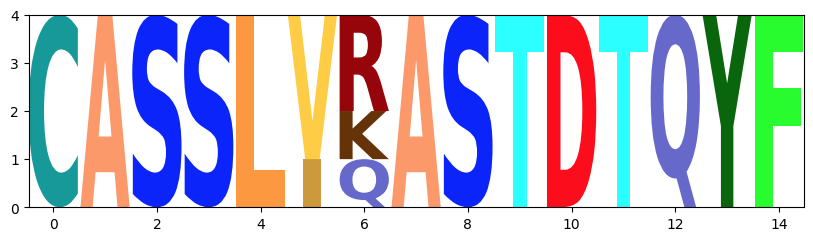

In [124]:
mat_df = logomaker.alignment_to_matrix(df[df.merged_cluster_id == 4514].cdr3aa_beta)
logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)
# df[df.merged_cluster_id == 2309]

In [134]:
from mir.basic.pgen import OlgaModel
from mir.basic.sampling import RepertoireSampling
from mir.basic.segment_usage import *
from mir.biomarkers.fisher_biomarkers_detector import FisherBiomarkersDetector
from mir.common.clonotype import ClonotypeAA
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.parser import *
from mir.common.repertoire import Repertoire
from mir.common.repertoire_dataset import RepertoireDataset
from mir.comparative.pair_matcher import ClonotypeRepresentation
from mir.comparative.pair_matcher import PairMatcher

In [135]:
t0 = time.time()
dataset = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/emerson/airr_format/{r}.tsv' for r in samples], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 22/22 [01:43<00:00,  4.72s/it]


104.53006601333618


In [136]:
dataset.pair_matcher = PairMatcher(clonotype_representation_method='cdr3aa,vj',
                                   clonotype_comparison_method='full',)

In [137]:
dataset.mismatch_max = 0

In [138]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb_valid,vdjdb_nonvalid,merged_cluster_id,pgen
0,s_22,HIP00594_c0,CASSLDAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594,False,False,0,NaN
1,s_10307,HIP00594_c0,CASSLDSYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594,False,False,0,NaN
2,b_594538,HIP00594_c0,CASSLNAYEQYF,TRBV4-2*01,TRBJ2-7*01,background,HIP00594,False,False,0,NaN
3,s_41,HIP00594_c2,CASSEGTGGTDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,False,1,NaN
4,s_42248,HIP00594_c2,CASSDGAGGRDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,False,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
13956,s_261169,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,sample,HIP15854,False,False,25717,NaN
13957,b_85098,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,background,HIP15854,False,False,25717,NaN
13958,s_261268,HIP15854_c19999,CASRLAGTTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854,False,False,15603,NaN
13959,s_261294,HIP15854_c19999,CAWRIAGNTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854,False,False,15603,NaN


In [139]:
public_clonotypes = df.apply(lambda x: ClonotypeRepresentation(cdr3aa=x.cdr3aa_beta, v=x.v_beta, j=x.j_beta), axis=1)

In [140]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb_valid,vdjdb_nonvalid,merged_cluster_id,pgen
0,s_22,HIP00594_c0,CASSLDAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594,False,False,0,NaN
1,s_10307,HIP00594_c0,CASSLDSYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,HIP00594,False,False,0,NaN
2,b_594538,HIP00594_c0,CASSLNAYEQYF,TRBV4-2*01,TRBJ2-7*01,background,HIP00594,False,False,0,NaN
3,s_41,HIP00594_c2,CASSEGTGGTDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,False,1,NaN
4,s_42248,HIP00594_c2,CASSDGAGGRDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,False,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
13956,s_261169,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,sample,HIP15854,False,False,25717,NaN
13957,b_85098,HIP15854_c13927,CASSDRTGTNTGELFF,TRBV6-1*01,TRBJ2-2*01,background,HIP15854,False,False,25717,NaN
13958,s_261268,HIP15854_c19999,CASRLAGTTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854,False,False,15603,NaN
13959,s_261294,HIP15854_c19999,CAWRIAGNTDTQYF,TRBV30*01,TRBJ2-3*01,sample,HIP15854,False,False,15603,NaN


In [141]:
public_clonotypes= public_clonotypes.reset_index(drop=True)

In [142]:
public_clonotypes = list(public_clonotypes)

In [143]:
public_clonotypes[10]

ClonotypeRepresentation(cdr3aa='CASSFLEGTDTQYF', v='TRBV6-6*01', j='TRBJ2-3*01', cdr3nt=None)

In [144]:
public_clono_set = set(public_clonotypes)

In [145]:
len(public_clono_set)

160095

In [148]:
from collections import defaultdict

In [149]:
clonotype_idx_to_patients = defaultdict(set)
for patient in dataset:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients[i].add(patient)

In [154]:
metadata_h =pd.DataFrame({'sample_name': ['control_ebv']})

In [155]:
metadata_h

,sample_name
0,control_ebv


In [156]:
t0 = time.time()
dataset_h = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata_h,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/emerson/airr_format/{r}.tsv' for r in metadata_h.sample_name], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 1/1 [00:38<00:00, 38.49s/it]


39.590216875076294


In [157]:
clonotype_idx_to_patients_h = defaultdict(set)
for patient in dataset_h:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients_h[i].add(patient)

In [158]:
df = df.reset_index(drop=True)

In [179]:
utils.get_cluster_usage(df, 5, , print_info=True)

1

In [180]:
len(clonotype_idx_to_patients[5])

2

In [185]:
summary['ebv_usage'] = summary.merged_cluster_id.apply(lambda x: utils.get_cluster_usage(df, x, clonotype_idx_to_patients))

In [186]:
summary['ebv_usage'].sum()

74616

In [187]:
summary[summary.n_patients > 3].sort_values(by=['sample_fraction', 'n_patients'], ascending=False).head(60).reset_index(drop=True)

,merged_cluster_id,cluster_size,n_patients,vdjdb_valid,background,sample,sample_fraction,background_fraction,ebv_usage
0,32,42,9,True,0,42,1.000000,0.000000,17
1,1419,23,5,False,0,23,1.000000,0.000000,9
2,4773,21,5,False,0,21,1.000000,0.000000,9
3,7058,18,4,False,0,18,1.000000,0.000000,9
4,3902,16,4,False,0,16,1.000000,0.000000,6
5,5131,17,5,False,1,16,0.941176,0.058824,10
6,1360,13,4,False,1,12,0.923077,0.076923,13
7,2074,13,4,False,1,12,0.923077,0.076923,7
8,2384,13,4,False,1,12,0.923077,0.076923,5
9,9280,13,4,False,1,12,0.923077,0.076923,12


In [ ]:
pgen_df = df.groupby('merged_cluster_id').agg({
    'pgen': 'mean'
}).reset_index()
pgen_df

In [ ]:
pgen_df['log_pgen'] = np.log10(pgen_df.pgen)

In [ ]:
pgen_df

In [ ]:
summary = summary.merge(pgen_df[['merged_cluster_id', 'log_pgen']])
summary

In [ ]:
summary['patient_fc'] = ((summary.as_usage + 1) / 28) / ((summary.h_usage + 1)/ 34)
summary['log_patient_fc'] = np.log10(summary['patient_fc'])

In [ ]:
summary['log_cluster_size'] = np.log10(summary['cluster_size'])

In [ ]:
selected_summary  = summary[summary.log_patient_fc > 0]
selected_summary

In [ ]:
selected_summary

In [ ]:
metrics = {
    'n_patients': 'benefit',
    'sample_fraction': 'benefit',
    'log_cluster_size': 'benefit',
    # 'log_pgen': 'cost',
    # 'log_patient_fc': 'benefit',
}
custom_weights = {
    'n_patients': 1.25,
    'sample_fraction': 1,
    'log_cluster_size': 2,
    # 'log_pgen': 1.0,
    # 'log_patient_fc': 1.5,
}
ranked_df = utils.compute_topsis_score(selected_summary, metrics, weight_dict=custom_weights)
ranked_df.head(20)

In [ ]:
ranked_df[['as_pattern', 'merged_cluster_id', 'cluster_size', 
           'n_patients', 'background', 'sample', 'sample_fraction', 
           'as_usage', 'h_usage', 
           # 'log_pgen', 
           'patient_fc', 'topsis_score']].head(20)

In [ ]:
df[df.merged_cluster_id == 8]

In [ ]:
utils.plot_logo(df[df.merged_cluster_id == 8].cdr3aa_beta)

In [ ]:
utils.plot_logo(df[df.merged_cluster_id == 2309].cdr3aa_beta)

In [ ]:
ranked_df[ranked_df['as_pattern']]

In [ ]:
sns.histplot(selected_summary.log_patient_fc)